# PPC #2 Cálculo Numérico
#### Encontrando raízes de polinômios usando o método de Bairstow

In [126]:
poly = []       # Onde os coeficientes dos polinômios são armazenados
err = 1e-8      # Margem de erro para considerar um valor como zero
max_iter = 200  # Máximo de iterações antes de o código considerar divergênci

#### Método de Bairstow

   O método de Bairstow é um procedimento numérico iterativo utilizado para encontrar raízes reais e complexas de polinômios com coeficientes reais. A ideia central é tentar fatorar o polinômio em fatores quadráticos da forma:

<p style="text-align:center;">$x² - rx - s$</p>

em que \(r\) e \(s\) são parâmetros ajustados iterativamente.

Considere um polinômio de grau \(n\), escrito como:

<p style="text-align:center;">$f(x)=a_0+a_1x+a_2x^2+\cdots+a_nx^n$</p>

No algoritmo, \(n\) representa o **grau atual do polinômio**, enquanto o índice \(i\) é usado para percorrer os coeficientes **de trás para frente** durante as recorrências.

A cada iteração, escolhem-se valores iniciais $r_0$ e $s_0$, e calculam-se dois vetores auxiliares:

- o vetor \(b\), usado na divisão do polinômio pelo fator $x²-rx-s$;
- o vetor \(c\), usado para calcular as correções de Newton para \(r\) e \(s\).

As recorrências para o vetor \(b\) são:

<p style="text-align:center;">$b_n=a_n$</p>

<p style="text-align:center;">$b_{n-1}=a_{n-1}+r\,b_n$</p>

<p style="text-align:center;">$b_i=a_i+r\,b_{i+1}+s\,b_{i+2}, \qquad i=n-2,n-3,\ldots,0$</p>

Ou seja, para calcular $b_i$, usam-se os dois valores já calculados à direita: $b_{i+1}$ e $b_{i+2}$.

Em seguida, calcula-se o vetor \(c\):

<p style="text-align:center;">$c_n=b_n$</p>

<p style="text-align:center;">$c_{n-1}=b_{n-1}+r\,c_n$</p>

<p style="text-align:center;">$c_i=b_i+r\,c_{i+1}+s\,c_{i+2}, \qquad i=n-2,n-3,\ldots,1
$</p>

Com os valores de \(b\) e \(c\), monta-se o sistema linear

<p style="text-align:center;">$c_1\Delta r + c_2\Delta s = -b_0$</p>

<p style="text-align:center;">$c_2\Delta r + c_3\Delta s = -b_1$</p>

A solução desse sistema fornece as correções $\Delta r$ e $\Delta s$, usadas para atualizar os parâmetros:

<p style="text-align:center;">$r_{\text{novo}} = r + \Delta r$</p>

<p style="text-align:center;">$s_{\text{novo}} = s + \Delta s$</p>

O processo é repetido até que os resíduos $b_0$ e $b_1$, ou então as correções $\Delta r$ e $\Delta s$, fiquem suficientemente pequenos.

Quando há convergência, o fator quadrático encontrado é:

<p style="text-align:center;">$x^2-rx-s$</p>

e suas duas raízes são dadas por:

<p style="text-align:center;">$x=\frac{r\pm\sqrt{r^2+4s}}{2}$</p>

Após encontrar esse par de raízes, o polinômio é deflacionado, e o método é reaplicado ao quociente até que todas as raízes sejam obtidas.

In [127]:
def bairstow_roots(poly, r0=5.0, s0=5.0, tol=1e-8, max_iter=200):
    """
    Encontra todas as raízes de um polinômio usando o método de Bairstow.

    Parâmetros
    ----------
    poly : list[float]
        Coeficientes do polinômio em ordem decrescente:
        [a_n, a_(n-1), ..., a_0]

    r0, s0 : float
        Chutes iniciais para os parâmetros do fator quadrático:
        x² - r*x - s

    tol : float
        Tolerância de convergência

    max_iter : int
        Número máximo de iterações para cada fator quadrático

    Retorna
    -------
    roots : list[complex]
        Lista com todas as raízes encontradas

    """

    def trim_leading_zeros(coeffs, eps=1e-8):
        coeffs = coeffs[:]
        while len(coeffs) > 1 and abs(coeffs[0]) < eps:
            coeffs.pop(0)
        return coeffs

    def quadratic_roots_from_rs(r, s):
        """
        Resolve as raízes de x² - r*x - s = 0
        """
        disc = complex(r*r + 4*s, 0.0)
        sqrt_disc = cmath.sqrt(disc)
        x1 = (r + sqrt_disc) / 2.0
        x2 = (r - sqrt_disc) / 2.0
        return x1, x2

    def find_one_quadratic_factor(coeffs_desc, r_init, s_init):
        """
        Encontra UM fator quadrático x² - r*x - s de um polinômio.
        """
        # Converte para ordem crescente:
        # [a_0, a_1, ..., a_n]
        a = list(reversed(coeffs_desc))

        # n = grau atual do polinômio
        n = len(a) - 1

        r = float(r_init)
        s = float(s_init)

        for iteration in range(max_iter):
            # b e c terão índices de 0 até n
            b = [0.0] * (n + 1)
            c = [0.0] * (n + 1)

            # -----------------------------------------
            # 1) Calcula os b_i
            # -----------------------------------------
            # b_n = a_n
            b[n] = a[n]

            # b_(n-1) = a_(n-1) + r*b_n
            b[n - 1] = a[n - 1] + r * b[n]

            # Agora i anda de n-2 até 0
            for i in range(n - 2, -1, -1):
                b[i] = a[i] + r * b[i + 1] + s * b[i + 2]

            # -----------------------------------------
            # 2) Calcula os c_i
            # -----------------------------------------
            # c_n = b_n
            c[n] = b[n]

            # c_(n-1) = b_(n-1) + r*c_n
            c[n - 1] = b[n - 1] + r * c[n]

            # Agora i anda de n-2 até 1
            # Ex.: se n=4, então i = 2, 1
            for i in range(n - 2, 0, -1):
                c[i] = b[i] + r * c[i + 1] + s * c[i + 2]

            # -----------------------------------------
            # 3) Resolve o sistema para delta_r e delta_s
            # -----------------------------------------
            # Sistema:
            # c1*dr + c2*ds = -b0
            # c2*dr + c3*ds = -b1
            #
            # onde:
            # c1 = c[1]
            # c2 = c[2]
            # c3 = c[3]
            #
            # Determinante do sistema:
            det = c[1] * c[3] - c[2] * c[2]

            # Se o determinante ficar muito pequeno,
            # fazemos uma mini intervenção e tentamos seguir...
            if abs(det) < 1e-14:
                r += 1e-3
                s += 1e-3
                continue

            # Fórmulas de Cramer (para nosso caso aqui, não é tão pesado)
            dr = (b[1] * c[2] - b[0] * c[3]) / det
            ds = (b[0] * c[2] - b[1] * c[1]) / det

            # Atualiza r e s
            r += dr
            s += ds

            # Stop quando tivermos:
            # resíduos pequenos e correções pequenas
            if max(abs(b[0]), abs(b[1])) < tol and max(abs(dr), abs(ds)) < tol:
                # O quociente da divisão está em b[2], b[3], ..., b[n]
                # mas em ordem crescente... então invertemos de volta
                quotient_desc = list(reversed(b[2:]))
                root1, root2 = quadratic_roots_from_rs(r, s)
                return True, quotient_desc, [root1, root2]

        return False, coeffs_desc, []

    # -------------------------------------------------
    # O corpo principal do algoritmo
    # -------------------------------------------------
    coeffs_desc = trim_leading_zeros(poly)
    roots = []

    # Enquanto o polinômio tiver grau maior que 2,
    # prosseguimos por deflacioná-lo
    while len(coeffs_desc) > 3:
        converged, quotient_desc, pair_roots = find_one_quadratic_factor(
            coeffs_desc, r0, s0
        )

        if not converged:
            raise RuntimeError("O método de Bairstow não convergiu para o fator atual :(")

        roots.extend(pair_roots)
        coeffs_desc = trim_leading_zeros(quotient_desc)

    # -------------------------------------------------
    # Resolve o que sobrou no final
    # -------------------------------------------------
    degree_left = len(coeffs_desc) - 1

    if degree_left == 2:
        a2, a1, a0 = coeffs_desc
        disc = complex(a1*a1 - 4*a2*a0, 0.0)
        sqrt_disc = cmath.sqrt(disc)
        roots.append((-a1 + sqrt_disc) / (2*a2))
        roots.append((-a1 - sqrt_disc) / (2*a2))

    elif degree_left == 1:
        a1, a0 = coeffs_desc
        roots.append(-a0 / a1)

    return roots

#### Bloco de funções auxiliares para o item 2

Para validar o método com um polinômio de ordem 7, serão usadas duas funções:

- `polynomial_from_roots(roots)`: constrói os coeficientes do polinômio a partir de um conjunto de raízes conhecidas;
- `match_roots(expected, found)`: associa cada raiz esperada à raiz numérica encontrada mais próxima, permitindo comparar os resultados e calcular os erros.

Essas funções não calculam raízes numericamente. Elas apenas auxiliam na construção do caso de teste e na análise da validação.

In [128]:
def multiply_polynomials(p, q):
    """
    Multiplica dois polinômios com coeficientes em ordem decrescente.

    Exemplo:
    p = [1, -3]      -> x - 3
    q = [1,  2]      -> x + 2

    retorno:
    [1, -1, -6]      -> x² - x - 6
    """
    result = [0] * (len(p) + len(q) - 1)

    for i in range(len(p)):
        for j in range(len(q)):
            result[i + j] += p[i] * q[j]

    return result


def polynomial_from_roots(roots, tol=1e-12):
    """
    Constrói um polinômio a partir de suas raízes conhecidas.

    Entrada:
    roots = [r1, r2, ..., rk]

    Saída:
    coeficientes em ordem decrescente:
    [a_n, a_(n-1), ..., a_0]

    O polinômio gerado é:
    (x - r1)(x - r2)...(x - rk)
    """
    poly = [1]

    for root in roots:
        factor = [1, -root]   # representa (x - root)
        poly = multiply_polynomials(poly, factor)

    # Se o imaginário residual for muito pequeno, remove
    cleaned_poly = []
    for coef in poly:
        coef_complex = complex(coef)
        if abs(coef_complex.imag) < tol:
            cleaned_poly.append(float(coef_complex.real))
        else:
            cleaned_poly.append(coef)

    return cleaned_poly


def match_roots(expected, found):
    """
    Associa cada raiz esperada à raiz encontrada mais próxima.

    Retorna uma lista de pares:
    [(expected_1, found_1), (expected_2, found_2), ...]
    """
    remaining_found = list(found)
    pairs = []

    for exp_root in expected:
        best_index = None
        best_distance = None

        for i, found_root in enumerate(remaining_found):
            distance = abs(exp_root - found_root)

            if best_distance is None or distance < best_distance:
                best_distance = distance
                best_index = i

        pairs.append((exp_root, remaining_found.pop(best_index)))

    return pairs

### Item 2 do PPC2: Teste da função `bairstow_roots()`
Para a verificação do código, será construído um polinômio de ordem 7 que possui raízes exatas:
<p style="text-align:center;">$x_1=1,\quad x_2=-2,\quad x_3=3,\quad x_4=-4,\quad x_5=-1,\quad x_6=2+3i,\quad x_7=2-3i$</p>

Objetivos para escolha dessas raízes:
* o polinômio resultante tenha coeficientes reais;
* haja uma combinação de raízes reais e complexas conjugadas;
* o teste seja mais representativo da capacidade do método.

A partir dessas raízes, o polinômio será construído por multiplicação sucessiva dos fatores lineares correspondentes. Em seguida, o método de Bairstow será aplicado para recuperar numericamente as raízes, e os resultados serão comparados com os valores exatos adotados.

A validação será considerada satisfatória se as raízes encontradas apresentarem erro absoluto inferior à tolerância numérica especificada.

In [129]:
# Raízes conhecidas:
expected_roots = [1, -2, 3, -4, -1, 2 + 3j, 2 - 3j]

# Constrói o polinômio a partir das raízes:
poly_validation = polynomial_from_roots(expected_roots)

print("Coeficientes do polinômio de validação:")
print(poly_validation)

# Aplica o método de Bairstow
found_roots = bairstow_roots(
    poly_validation,
    r0=5.0,
    s0=5.0,
    tol=err,
    max_iter=max_iter
)

print("\nRaízes encontradas pelo método:")
for i, root in enumerate(found_roots, start=1):
    print(f"x{i} = {root.real:.10f} {root.imag:+.10f}j")

# Associa raízes exatas às raízes encontradas
matched_pairs = match_roots(expected_roots, found_roots)

print("\nComparação entre raízes esperadas e encontradas:")
errors = []

for i, (expected, found) in enumerate(matched_pairs, start=1):
    abs_error = abs(expected - found)
    errors.append(abs_error)

    print(f"\nPar {i}:")
    print(f"  Esperada   = {expected}")
    print(f"  Encontrada = {found}")
    print(f"  Erro abs   = {abs_error:.3e}")

max_error = max(errors) if errors else 0.0
validation_ok = all(error < err for error in errors)

print("\n" + "=" * 60)
print("RESUMO DA VALIDAÇÃO")
print("=" * 60)
print(f"Erro absoluto máximo = {max_error:.3e}")

if validation_ok:
    print("Status: validação bem-sucedida.")
else:
    print("Status: validação NÃO atendida dentro da tolerância.")

Coeficientes do polinômio de validação:
[1.0, -1.0, -10.0, 56.0, -25.0, -367.0, 34.0, 312.0]

Raízes encontradas pelo método:
x1 = -2.0000000000 +0.0000000000j
x2 = -4.0000000000 +0.0000000000j
x3 = 3.0000000000 +0.0000000000j
x4 = 1.0000000000 +0.0000000000j
x5 = 2.0000000000 +3.0000000000j
x6 = 2.0000000000 -3.0000000000j
x7 = -1.0000000000 +0.0000000000j

Comparação entre raízes esperadas e encontradas:

Par 1:
  Esperada   = 1
  Encontrada = (0.9999999999998681+0j)
  Erro abs   = 1.319e-13

Par 2:
  Esperada   = -2
  Encontrada = (-2+0j)
  Erro abs   = 0.000e+00

Par 3:
  Esperada   = 3
  Encontrada = (3.0000000000000417+0j)
  Erro abs   = 4.174e-14

Par 4:
  Esperada   = -4
  Encontrada = (-4+0j)
  Erro abs   = 0.000e+00

Par 5:
  Esperada   = -1
  Encontrada = -1.0000000000308105
  Erro abs   = 3.081e-11

Par 6:
  Esperada   = (2+3j)
  Encontrada = (2.000000000000014+3.000000000000365j)
  Erro abs   = 3.653e-13

Par 7:
  Esperada   = (2-3j)
  Encontrada = (2.000000000000014-3.000

#### Análise da convergência para diferentes valores iniciais de $r_0$ e $s_0$

Nesta etapa, deseja-se investigar como a escolha dos valores iniciais $r_0$ e $s_0$ influencia o comportamento do método de Bairstow.

Como o método é iterativo e baseado em correções sucessivas dos parâmetros $r$ e $s$, diferentes chutes iniciais podem levar a comportamentos distintos, tais como:

- convergência rápida;
- convergência lenta;
- convergência para fatores quadráticos diferentes;
- dificuldade de convergência ou até divergência.

Para analisar esse efeito, será utilizada uma rotina auxiliar que executa apenas a busca de um único fator quadrático, registrando:

- se houve convergência;
- o número de iterações necessárias;
- os valores finais de $r$ e $s$;
- o par de raízes associado ao fator quadrático encontrado.

<p style="text-align:center;">$x^2 - rx - s$</p>

A partir disso, será possível comparar diferentes escolhas iniciais e discutir sua influência na estabilidade e na velocidade de convergência do método.

In [130]:
import cmath
import pandas as pd     # Só para deixar os resultados bonitos

def analyze_bairstow_convergence(poly, initial_guesses, tol=1e-8, max_iter=200):
    """
    Este não acha raízes, ele só analisa a convergência do método de Bairstow para vários pares iniciais (r0, s0).

    Parâmetros
    ----------
    poly : list[float]
        Coeficientes do polinômio em ordem decrescente:
        [a_n, a_(n-1), ..., a_0]

    initial_guesses : list[tuple[float, float]]
        Lista com os pares iniciais (r0, s0)

    tol : float
        Tolerância numérica

    max_iter : int
        Número máximo de iterações para cada par inicial

    Retorna
    -------
    results : list[dict]
        Lista com os resultados de cada par inicial
    """

    results = []

    a = list(reversed(poly))
    n = len(a) - 1

    for r0, s0 in initial_guesses:
        r = float(r0)
        s = float(s0)

        converged = False
        roots = []
        reason = "max_iter_excedido"

        for iteration in range(1, max_iter + 1):
            b = [0.0] * (n + 1)
            c = [0.0] * (n + 1)

            # ==========================================
            # 1) Cálculo dos coeficientes b_i
            # ==========================================
            b[n] = a[n]
            b[n - 1] = a[n - 1] + r * b[n]

            # i percorre: n-2, n-3, ..., 0
            for i in range(n - 2, -1, -1):
                b[i] = a[i] + r * b[i + 1] + s * b[i + 2]

            # ==========================================
            # 2) Cálculo dos coeficientes c_i
            # ==========================================
            c[n] = b[n]
            c[n - 1] = b[n - 1] + r * c[n]

            # i percorre: n-2, n-3, ..., 1
            for i in range(n - 2, 0, -1):
                c[i] = b[i] + r * c[i + 1] + s * c[i + 2]

            # ==========================================
            # 3) Sistema para delta_r e delta_s
            # ==========================================
            det = c[1] * c[3] - c[2] * c[2]

            if abs(det) < 1e-14:
                reason = "determinante_quase_nulo"
                break

            dr = (b[1] * c[2] - b[0] * c[3]) / det
            ds = (b[0] * c[2] - b[1] * c[1]) / det

            r += dr
            s += ds

            # Critério de parada
            if max(abs(b[0]), abs(b[1])) < tol and max(abs(dr), abs(ds)) < tol:
                converged = True
                reason = "convergiu"

                disc = complex(r * r + 4 * s, 0.0)
                sqrt_disc = cmath.sqrt(disc)

                root1 = (r + sqrt_disc) / 2.0
                root2 = (r - sqrt_disc) / 2.0
                roots = [root1, root2]

                break

        results.append({
            "r0": r0,
            "s0": s0,
            "converged": converged,
            "iterations": iteration,
            "r_final": r,
            "s_final": s,
            "roots": roots,
            "reason": reason
        })

    return results

Agora executando `analyze_bairstow_convergence()` para vários ($r_0$, $s_0$)

In [131]:
# ==========================================================
# ITEM 3 - Análise da convergência para diferentes r0 e s0
# ==========================================================

initial_guesses = [
    (0.0, 0.0),
    (1.0, 1.0),
    (2.0, 1.0),
    (3.0, 2.0),
    (5.0, 5.0),
    (-1.0, 1.0),
    (-2.0, -1.0),
    (4.0, -2.0),
]

results_item3 = analyze_bairstow_convergence(
    poly_validation,
    initial_guesses=initial_guesses,
    tol=err,
    max_iter=max_iter
)

print("=" * 80)
print("ANÁLISE DE CONVERGÊNCIA PARA DIFERENTES VALORES INICIAIS")
print("=" * 80)

for item in results_item3:
    print(f"\nr0 = {item['r0']:.2f}, s0 = {item['s0']:.2f}")
    print(f"Convergiu? {item['converged']}")
    print(f"Iterações: {item['iterations']}")
    print(f"r final: {item['r_final']:.10f}")
    print(f"s final: {item['s_final']:.10f}")
    print(f"Motivo de parada: {item['reason']}")

    if item["converged"]:
        print("Raízes do fator quadrático encontrado:")
        for root in item["roots"]:
            print(f"   {root.real:.10f} {root.imag:+.10f}j")

ANÁLISE DE CONVERGÊNCIA PARA DIFERENTES VALORES INICIAIS

r0 = 0.00, s0 = 0.00
Convergiu? True
Iterações: 6
r final: 0.0000000000
s final: 1.0000000000
Motivo de parada: convergiu
Raízes do fator quadrático encontrado:
   1.0000000000 +0.0000000000j
   -1.0000000000 +0.0000000000j

r0 = 1.00, s0 = 1.00
Convergiu? True
Iterações: 7
r final: 0.0000000000
s final: 1.0000000000
Motivo de parada: convergiu
Raízes do fator quadrático encontrado:
   1.0000000000 +0.0000000000j
   -1.0000000000 +0.0000000000j

r0 = 2.00, s0 = 1.00
Convergiu? True
Iterações: 9
r final: -1.0000000000
s final: 12.0000000000
Motivo de parada: convergiu
Raízes do fator quadrático encontrado:
   3.0000000000 +0.0000000000j
   -4.0000000000 +0.0000000000j

r0 = 3.00, s0 = 2.00
Convergiu? True
Iterações: 7
r final: 2.0000000000
s final: 3.0000000000
Motivo de parada: convergiu
Raízes do fator quadrático encontrado:
   3.0000000000 +0.0000000000j
   -1.0000000000 +0.0000000000j

r0 = 5.00, s0 = 5.00
Convergiu? True
Ite

#### Tabela para os resultados

In [132]:
rows = []

for item in results_item3:
    if item["converged"] and len(item["roots"]) == 2:
        root1 = item["roots"][0]
        root2 = item["roots"][1]
        root1_str = f"{root1.real:.6f} {root1.imag:+.6f}j"
        root2_str = f"{root2.real:.6f} {root2.imag:+.6f}j"
    else:
        root1_str = "-"
        root2_str = "-"

    rows.append({
        "r0": item["r0"],
        "s0": item["s0"],
        "convergiu": item["converged"],
        "iterações": item["iterations"],
        "r_final": item["r_final"],
        "s_final": item["s_final"],
        "raiz 1": root1_str,
        "raiz 2": root2_str,
        "motivo": item["reason"]
    })

df_item3 = pd.DataFrame(rows)
df_item3

,r0,s0,convergiu,iterações,r_final,s_final,raiz 1,raiz 2,motivo
0,0.0,0.0,True,6,7.639810e-18,1.0,1.000000 +0.000000j,-1.000000 +0.000000j,convergiu
1,1.0,1.0,True,7,5.419679e-20,1.0,1.000000 +0.000000j,-1.000000 +0.000000j,convergiu
2,2.0,1.0,True,9,-1.000000e+00,12.0,3.000000 +0.000000j,-4.000000 +0.000000j,convergiu
3,3.0,2.0,True,7,2.000000e+00,3.0,3.000000 +0.000000j,-1.000000 +0.000000j,convergiu
4,5.0,5.0,True,16,-6.000000e+00,-8.0,-2.000000 +0.000000j,-4.000000 +0.000000j,convergiu
5,-1.0,1.0,True,14,-1.000000e+00,12.0,3.000000 +0.000000j,-4.000000 +0.000000j,convergiu
6,-2.0,-1.0,True,64,-1.000000e+00,12.0,3.000000 +0.000000j,-4.000000 +0.000000j,convergiu
7,4.0,-2.0,True,6,4.000000e+00,-3.0,3.000000 +0.000000j,1.000000 +0.000000j,convergiu


#### Aplicação do método ao polinômio característico obtido na APC2

Nesta etapa, o método de Bairstow será aplicado ao polinômio característico obtido anteriormente na APC2, com o objetivo de determinar os autovalores do sistema dinâmico estudado.

No caso considerado, o polinômio característico encontrado foi:

<p style="text-align:center;">$P(\lambda) = 4.44\lambda^4 + 40.205\lambda^3 + 9863.64\lambda^2 + 37417\lambda + 4537400$</p>

Assim, os coeficientes do polinômio serão fornecidos ao algoritmo, e as raízes encontradas corresponderão aos autovalores do sistema.

Como se trata de um sistema dinâmico amortecido com múltiplos graus de liberdade, espera-se obter autovalores que podem ser reais ou complexos. A presença de parte imaginária está associada a comportamento oscilatório, enquanto a parte real está associada ao crescimento, decaimento e estabilidade da resposta.

In [133]:
poly_apc2 = [4.44, 40.205, 9863.64, 37417.0, 4537400.0]

autovalores_apc2 = bairstow_roots(
    poly_apc2,
    r0=5.0,
    s0=5.0,
    tol=err,
    max_iter=max_iter
)

autovalores_apc2_sorted = sorted(
    autovalores_apc2,
    key=lambda z: (round(z.real, 12), round(z.imag, 12))
)

print("=" * 60)
print("AUTOVALORES ORDENADOS")
print("=" * 60)

for i, lam in enumerate(autovalores_apc2_sorted, start=1):
    print(f"λ{i} = {lam.real:.12f} {lam.imag:+.12f}j")

AUTOVALORES ORDENADOS
λ1 = -3.147960258195 -39.129231982788j
λ2 = -3.147960258195 +39.129231982788j
λ3 = -1.379629831895 -25.714949605048j
λ4 = -1.379629831895 +25.714949605048j


#### Interpretação física dos autovalores obtidos (item 5)

Os autovalores obtidos para o sistema foram:

<p style="text-align:center;">$\lambda_1 = -3.147960258195 - 39.129231982788j$</p>
<p style="text-align:center;">$\lambda_2 = -3.147960258195 + 39.129231982788j$</p>
<p style="text-align:center;">$\lambda_3 = -1.379629831895 - 25.714949605048j$</p>
<p style="text-align:center;">$\lambda_4 = -1.379629831895 + 25.714949605048j$</p>

Observa-se que todos os autovalores possuem parte real negativa. Isso indica que a resposta do sistema decai com o tempo, ou seja, o sistema é estavelmente amortecido.

Além disso, todos os autovalores possuem parte imaginária não nula, o que caracteriza comportamento oscilatório. Portanto, os modos associados a esses autovalores são modos oscilatórios amortecidos.

De forma geral, para um autovalor complexo da forma $\lambda = \alpha + \beta j$:

- a parte real $\alpha$ está associada ao decaimento ou crescimento da amplitude;
- a parte imaginária $\beta$ , por sua vez, à frequência angular de oscilação.

No caso, como $\alpha < 0$ para todos os autovalores, conclui-se que nenhum modo é instável. Quanto aos valores absolutos das partes imaginárias, esses indicam duas frequências oscilatórias distintas, associadas aos dois modos do sistema.

O par de autovalores com parte imaginária de maior magnitude, aproximadamente $\pm 39.1292j$, corresponde ao modo de maior frequência. Já o par com parte imaginária de menor magnitude, aproximadamente $\pm 25.7149j$, corresponde ao modo de menor frequência.

Comparando as partes reais, nota-se que o primeiro par apresenta decaimento mais rápido, pois $-3.1479 < -1.3796$. Assim, esse modo perde amplitude mais rapidamente do que o segundo.

Destarte, os resultados obtidos anunciam que o sistema apresenta dois modos vibratórios amortecidos, estáveis, com frequências distintas e taxas de amortecimento diferentes.

In [134]:
# O "tchan" final ;)
print("=" * 70)
print("INTERPRETAÇÃO FÍSICA DOS AUTOVALORES")
print("=" * 70)

for i, lam in enumerate(autovalores_apc2_sorted, start=1):
    alpha = lam.real
    beta = abs(lam.imag)

    print(f"\nAutovalor λ{i} = {lam.real:.12f} {lam.imag:+.12f}j")
    print(f"Parte real (taxa de decaimento): {alpha:.12f}")
    print(f"Parte imaginária em módulo (frequência angular): {beta:.12f} rad/s")

    if alpha < 0:
        print("Interpretação: modo estável e amortecido.")
    elif alpha > 0:
        print("Interpretação: modo instável.")
    else:
        print("Interpretação: modo com estabilidade neutra.")

    if beta > 0:
        print("Comportamento: oscilatório.")
    else:
        print("Comportamento: não oscilatório.")

INTERPRETAÇÃO FÍSICA DOS AUTOVALORES

Autovalor λ1 = -3.147960258195 -39.129231982788j
Parte real (taxa de decaimento): -3.147960258195
Parte imaginária em módulo (frequência angular): 39.129231982788 rad/s
Interpretação: modo estável e amortecido.
Comportamento: oscilatório.

Autovalor λ2 = -3.147960258195 +39.129231982788j
Parte real (taxa de decaimento): -3.147960258195
Parte imaginária em módulo (frequência angular): 39.129231982788 rad/s
Interpretação: modo estável e amortecido.
Comportamento: oscilatório.

Autovalor λ3 = -1.379629831895 -25.714949605048j
Parte real (taxa de decaimento): -1.379629831895
Parte imaginária em módulo (frequência angular): 25.714949605048 rad/s
Interpretação: modo estável e amortecido.
Comportamento: oscilatório.

Autovalor λ4 = -1.379629831895 +25.714949605048j
Parte real (taxa de decaimento): -1.379629831895
Parte imaginária em módulo (frequência angular): 25.714949605048 rad/s
Interpretação: modo estável e amortecido.
Comportamento: oscilatório.


#### Varredura sistemática dos valores iniciais $r_0$ e $s_0$

Nesta etapa, será realizada uma varredura sistemática dos valores iniciais $r_0$ e $s_0$ no plano bidimensional, com o objetivo de registrar o comportamento de convergência do método de Bairstow.

A ideia consiste em definir uma malha regular de pontos no plano $(r,s)$ e, para cada par inicial $(r_0, s_0)$, executar o método iterativo correspondente à busca de um fator quadrático da forma:

<p style="text-align:center;">$x^2 - rx - s$</p>

Como os valores de convergência de $r$ e $s$ dependem do polinômio em estudo, o intervalo de varredura foi escolhido de modo compatível com a escala dos fatores quadráticos associados ao polinômio característico da APC2.

Para cada ponto da malha, serão registrados os seguintes dados:

- se houve convergência ou não;
- o número de iterações necessárias;
- os valores finais de $r$ e $s$;
- o par de raízes associado ao fator quadrático encontrado.

Essas informações permitirão analisar as regiões de convergência do método e servirão de base para a construção do fractal de Bairstow do item 7.

#### Mecanismo de Varredura

In [135]:
import cmath
import numpy as np

def scan_bairstow_plane(poly, r_min, r_max, s_min, s_max, n_r=120, n_s=120, tol=1e-8, max_iter=200):
    """
    Faz uma varredura do plano (r0, s0) para o método de Bairstow.

    Parâmetros
    ----------
    poly : list[float]
        Coeficientes do polinômio em ordem decrescente:
        [a_n, a_(n-1), ..., a_0]

    r_min, r_max : float
        Limites do eixo r

    s_min, s_max : float
        Limites do eixo s

    n_r, n_s : int
        Número de pontos da malha em r e s

    tol : float
        Tolerância de convergência

    max_iter : int
        Número máximo de iterações por ponto

    Retorna
    -------
    dict
        Estrutura com a malha e os resultados da varredura
    """

    # Converte para ordem crescente: [a_0, a_1, ..., a_n]
    a = list(reversed(poly))
    n = len(a) - 1

    r_values = np.linspace(r_min, r_max, n_r)
    s_values = np.linspace(s_min, s_max, n_s)

    # Matrizes de saída
    converged_map = np.zeros((n_s, n_r), dtype=bool)
    iterations_map = np.full((n_s, n_r), -1, dtype=int)
    r_final_map = np.full((n_s, n_r), np.nan, dtype=float)
    s_final_map = np.full((n_s, n_r), np.nan, dtype=float)

    root1_map = np.full((n_s, n_r), np.nan + 0j, dtype=complex)
    root2_map = np.full((n_s, n_r), np.nan + 0j, dtype=complex)

    for j, s0 in enumerate(s_values):
        for i, r0 in enumerate(r_values):
            r = float(r0)
            s = float(s0)

            converged = False

            for iteration in range(1, max_iter + 1):
                b = [0.0] * (n + 1)
                c = [0.0] * (n + 1)

                # ==========================================
                # 1) Cálculo dos coeficientes b_i
                # ==========================================
                b[n] = a[n]
                b[n - 1] = a[n - 1] + r * b[n]

                for k in range(n - 2, -1, -1):
                    b[k] = a[k] + r * b[k + 1] + s * b[k + 2]

                # ==========================================
                # 2) Cálculo dos coeficientes c_i
                # ==========================================
                c[n] = b[n]
                c[n - 1] = b[n - 1] + r * c[n]

                for k in range(n - 2, 0, -1):
                    c[k] = b[k] + r * c[k + 1] + s * c[k + 2]

                # ==========================================
                # 3) Sistema para delta_r e delta_s
                # ==========================================
                det = c[1] * c[3] - c[2] * c[2]

                if abs(det) < 1e-14:
                    break

                dr = (b[1] * c[2] - b[0] * c[3]) / det
                ds = (b[0] * c[2] - b[1] * c[1]) / det

                r += dr
                s += ds

                if max(abs(b[0]), abs(b[1])) < tol and max(abs(dr), abs(ds)) < tol:
                    converged = True

                    disc = complex(r * r + 4 * s, 0.0)
                    sqrt_disc = cmath.sqrt(disc)

                    root1 = (r + sqrt_disc) / 2.0
                    root2 = (r - sqrt_disc) / 2.0

                    converged_map[j, i] = True
                    iterations_map[j, i] = iteration
                    r_final_map[j, i] = r
                    s_final_map[j, i] = s
                    root1_map[j, i] = root1
                    root2_map[j, i] = root2
                    break

            if not converged:
                iterations_map[j, i] = max_iter

    return {
        "r_values": r_values,
        "s_values": s_values,
        "converged_map": converged_map,
        "iterations_map": iterations_map,
        "r_final_map": r_final_map,
        "s_final_map": s_final_map,
        "root1_map": root1_map,
        "root2_map": root2_map
    }

#### Varredura

In [136]:
scan_item6 = scan_bairstow_plane(
    poly_apc2,      # Configurações para uma janela gráfica mais ampla
    r_min=-8.0,    # -10.0
    r_max=0.0,      # 2.0
    s_min=-1700.0,  # -1800.0
    s_max=-400.0,    # 100.0
    n_r=500,        # 250
    n_s=500,        # 250
    tol=err,
    max_iter=max_iter
)

print("=" * 60)
print("VARREDURA DO PLANO (r0, s0) CONCLUÍDA")
print("=" * 60)

total_points = scan_item6["converged_map"].size
converged_points = np.count_nonzero(scan_item6["converged_map"])
failed_points = total_points - converged_points

print(f"Total de pontos avaliados: {total_points}")
print(f"Pontos com convergência:   {converged_points}")
print(f"Pontos sem convergência:   {failed_points}")
print(f"Taxa de convergência:      {100 * converged_points / total_points:.2f}%")

VARREDURA DO PLANO (r0, s0) CONCLUÍDA
Total de pontos avaliados: 250000
Pontos com convergência:   250000
Pontos sem convergência:   0
Taxa de convergência:      100.00%


debug antes do item 7:

In [137]:
# Mostra alguns pontos convergentes da malha
r_values = scan_item6["r_values"]
s_values = scan_item6["s_values"]
conv_map = scan_item6["converged_map"]
iter_map = scan_item6["iterations_map"]
root1_map = scan_item6["root1_map"]
root2_map = scan_item6["root2_map"]

print("=" * 60)
print("AMOSTRA DE PONTOS CONVERGENTES")
print("=" * 60)

shown = 0
for j in range(len(s_values)):
    for i in range(len(r_values)):
        if conv_map[j, i]:
            print(f"r0 = {r_values[i]:.3f}, s0 = {s_values[j]:.3f}")
            print(f"iterações = {iter_map[j, i]}")
            print(f"raiz 1 = {root1_map[j, i]}")
            print(f"raiz 2 = {root2_map[j, i]}")
            print("-" * 40)

            shown += 1
            if shown >= 5:
                break
    if shown >= 5:
        break

AMOSTRA DE PONTOS CONVERGENTES
r0 = -8.000, s0 = -1700.000
iterações = 6
raiz 1 = (-3.1479602581953645+39.12923198278828j)
raiz 2 = (-3.1479602581953645-39.12923198278828j)
----------------------------------------
r0 = -7.984, s0 = -1700.000
iterações = 6
raiz 1 = (-3.147960258195364+39.12923198278828j)
raiz 2 = (-3.147960258195364-39.12923198278828j)
----------------------------------------
r0 = -7.968, s0 = -1700.000
iterações = 6
raiz 1 = (-3.147960258195364+39.12923198278828j)
raiz 2 = (-3.147960258195364-39.12923198278828j)
----------------------------------------
r0 = -7.952, s0 = -1700.000
iterações = 6
raiz 1 = (-3.147960258195364+39.12923198278828j)
raiz 2 = (-3.147960258195364-39.12923198278828j)
----------------------------------------
r0 = -7.936, s0 = -1700.000
iterações = 6
raiz 1 = (-3.147960258195364+39.12923198278828j)
raiz 2 = (-3.147960258195364-39.12923198278828j)
----------------------------------------


#### Construção do fractal de Bairstow (item 7)

A partir da varredura sistemática realizada no item anterior, é possível construir uma representação visual do comportamento de convergência do método de Bairstow no plano dos valores iniciais $(r_0, s_0)$.

Neste trabalho, serão utilizadas duas visualizações complementares:

- um mapa do número de iterações necessárias para a convergência;
- um mapa das regiões de atração, indicando para qual fator quadrático o método converge a partir de cada par inicial $(r_0, s_0)$.

Essas figuras permitem identificar regiões de convergência, zonas de instabilidade e padrões estruturais associados à dinâmica iterativa do método.

No caso do polinômio estudado, como foram obtidos dois pares de autovalores complexos conjugados, espera-se observar regiões do plano $(r,s)$ associadas a cada um desses dois fatores quadráticos.

###### _(Favor, não repetir tarefas desse nível de labor. Grato!)_

#### Algoritmo de classificação das regiões de convergência

In [138]:
# Pares esperados de autovalores obtidos no item 4:
expected_pairs = [
    [autovalores_apc2_sorted[0], autovalores_apc2_sorted[1]],
    [autovalores_apc2_sorted[2], autovalores_apc2_sorted[3]],
]

def pair_distance(pair_a, pair_b):
    """
    Mede a distância entre dois pares de raízes complexas,
    desconsiderando a ordem dentro do par.
    """
    d1 = abs(pair_a[0] - pair_b[0]) + abs(pair_a[1] - pair_b[1])
    d2 = abs(pair_a[0] - pair_b[1]) + abs(pair_a[1] - pair_b[0])
    return min(d1, d2)

converged_map = scan_item6["converged_map"]
root1_map = scan_item6["root1_map"]
root2_map = scan_item6["root2_map"]

# family_map:
# -1 -> não convergiu
#  0 -> convergiu para o primeiro par
#  1 -> convergiu para o segundo par
family_map = np.full(converged_map.shape, -1, dtype=int)

for j in range(converged_map.shape[0]):
    for i in range(converged_map.shape[1]):
        if converged_map[j, i]:
            found_pair = [root1_map[j, i], root2_map[j, i]]

            distances = [
                pair_distance(found_pair, expected_pairs[0]),
                pair_distance(found_pair, expected_pairs[1]),
            ]

            family_map[j, i] = int(np.argmin(distances))

print("Classificação das famílias de convergência concluída.")

Classificação das famílias de convergência concluída.


#### O mapa do número de iterações

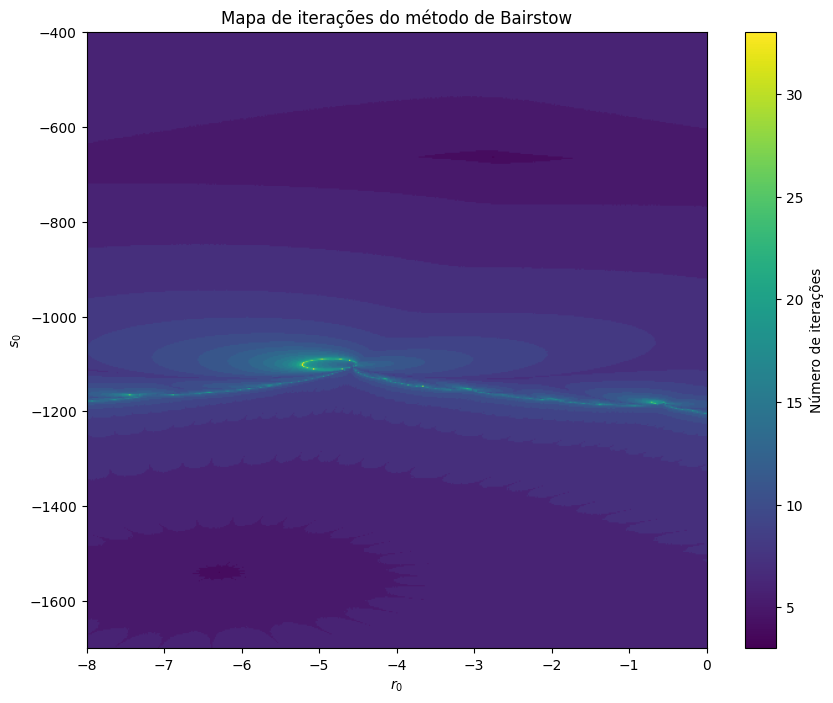

In [139]:
import matplotlib.pyplot as plt

r_values = scan_item6["r_values"]
s_values = scan_item6["s_values"]
iterations_map = scan_item6["iterations_map"]

# Máscara para destacar apenas pontos convergentes
iterations_masked = np.ma.masked_where(~converged_map, iterations_map)

plt.figure(figsize=(10, 8))
plt.imshow(
    iterations_masked,
    extent=[r_values[0], r_values[-1], s_values[0], s_values[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Número de iterações")
plt.xlabel("$r_0$")
plt.ylabel("$s_0$")
plt.title("Mapa de iterações do método de Bairstow")
plt.show()

#### Gráfico das regiões de atração do método
Para ilustrar para qual par de raízes o método convergiu, ao final das contas.

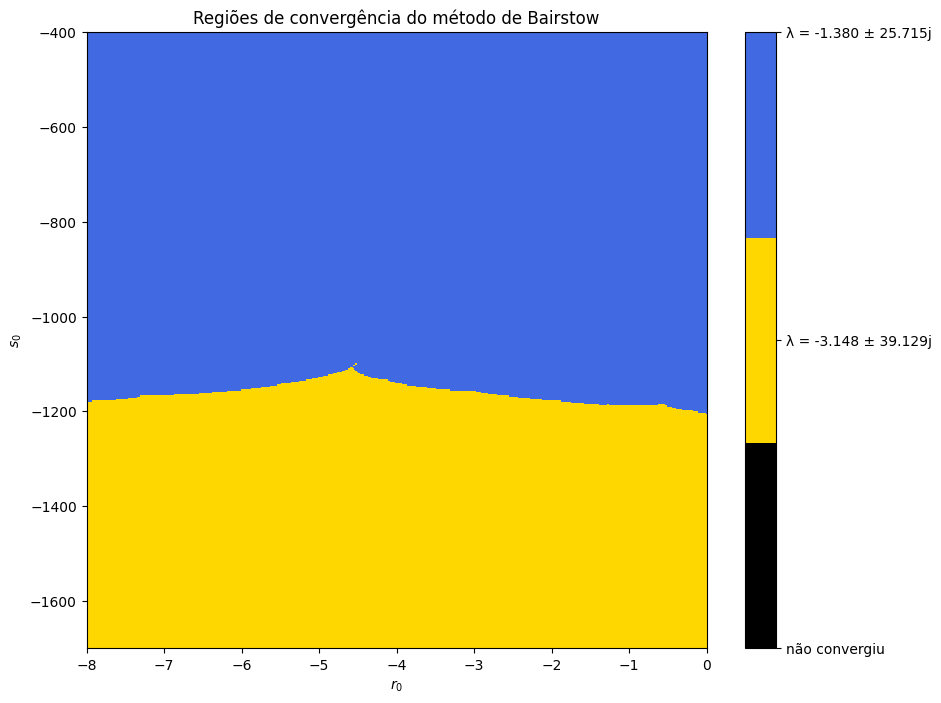

In [140]:
from matplotlib.colors import ListedColormap

# Vamos desenhar:
# -1 -> não convergiu
#  0 -> família 1
#  1 -> família 2
#
# Para o imshow, deslocamos os valores em +1:
# -1 -> 0
#  0 -> 1
#  1 -> 2
family_plot = family_map + 1

cmap = ListedColormap(["black", "gold", "royalblue"])

plt.figure(figsize=(10, 8))
plt.imshow(
    family_plot,
    extent=[r_values[0], r_values[-1], s_values[0], s_values[-1]],
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
    interpolation="nearest"
)

cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels([
    "não convergiu",
    "λ = -3.148 ± 39.129j",
    "λ = -1.380 ± 25.715j"
])

plt.xlabel("$r_0$")
plt.ylabel("$s_0$")
plt.title("Regiões de convergência do método de Bairstow")
plt.show()

#### Salvar imagens, se quiser

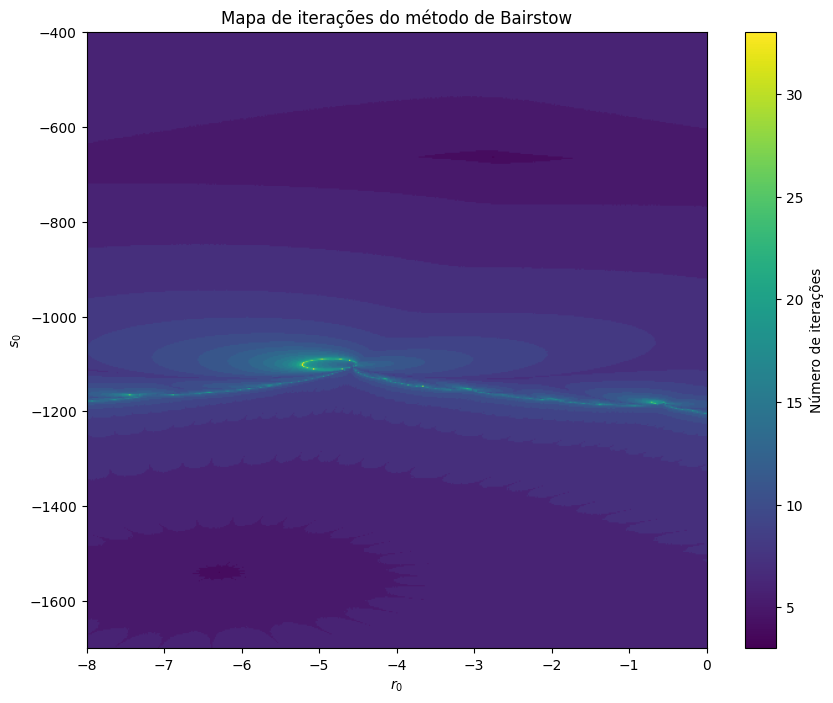

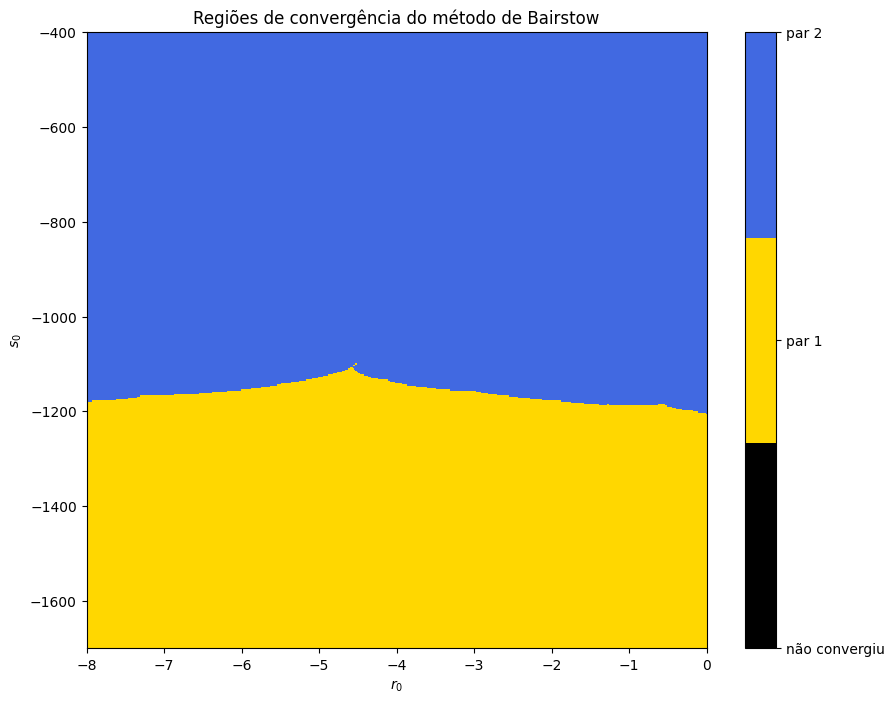

In [141]:
plt.figure(figsize=(10, 8))
plt.imshow(
    iterations_masked,
    extent=[r_values[0], r_values[-1], s_values[0], s_values[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Número de iterações")
plt.xlabel("$r_0$")
plt.ylabel("$s_0$")
plt.title("Mapa de iterações do método de Bairstow")
plt.savefig("bairstow_iterations_apc2.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(
    family_plot,
    extent=[r_values[0], r_values[-1], s_values[0], s_values[-1]],
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=2,
    interpolation="nearest"
)
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.ax.set_yticklabels([
    "não convergiu",
    "par 1",
    "par 2"
])
plt.xlabel("$r_0$")
plt.ylabel("$s_0$")
plt.title("Regiões de convergência do método de Bairstow")
plt.savefig("bairstow_families_apc2.png", dpi=300, bbox_inches="tight")
plt.show()

#### Interpretação do fractal de Bairstow

As figuras obtidas mostram que o comportamento do método de Bairstow depende fortemente da escolha dos valores iniciais $(r_0, s_0)$.

O mapa do número de iterações indica que, em grande parte do domínio analisado, o método converge em poucas iterações. Entretanto, observa-se uma faixa de transição entre as regiões de convergência na qual o número de iterações aumenta significativamente. Essa faixa corresponde a uma região de maior sensibilidade aos valores iniciais.

O mapa das regiões de convergência mostra a existência de duas bacias de atração bem definidas, cada uma associada a um dos dois fatores quadráticos correspondentes aos pares de autovalores complexos conjugados obtidos para o polinômio da APC2.

A fronteira entre essas bacias não é linear e apresenta uma estrutura curva no plano $(r,s)$, evidenciando que pequenas variações nos valores iniciais podem fazer o método convergir para fatores diferentes. Esse comportamento é característico da dinâmica iterativa do método de Bairstow.

Assim, os resultados da varredura mostram que:

- diferentes escolhas iniciais $(r_0, s_0)$ podem conduzir a diferentes fatores quadráticos;
- a velocidade de convergência não é uniforme em todo o plano;
- existem regiões mais sensíveis, nas quais o método exige mais iterações para convergir.

Esses padrões constituem a representação visual do fractal de Bairstow para o polinômio em estudo.